### 第9章 图像梯度
- 一般情况下，图像梯度计算的是图像的边缘信息。严格来讲，图像梯度需要计算导数，但一般可通过计算像素值的差来得到梯度的近似值。
- 使用不同的卷积核能够实现不同的效果
    - 平滑：$ k = \dfrac{1}{9} \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix} $ 使用邻域像素均值替换当前像素点的值
    - 复制：$ k = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0 \end{bmatrix} $ 当前像素点权重为1，周围邻域像素点权重均为0
    - 锐化：$ k = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix} $ 当前像素点值的5倍减去周围像素点的值
    - 边缘：$ k = \begin{bmatrix} -1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1 \end{bmatrix} $ 当前像素点值的8倍减去邻域内其他像素点的值

#### 9.1 Sobel算子
- 滤波器通常是指由一幅图像的像素点(x, y)临近的区域计算得到另外一幅图像的算法
- 滤波器也被称为“核”、“模板”、“窗口”、“算子”、“掩膜（掩码）”等，这里用“算子”表示卷积运算所使用的滤波器
- Sobel 算子是一种离散的微分算子，结合了高斯平滑核微分求导运算。该算子利用局部差分寻找边缘，得到的是梯度的近似值。
- 计算水平方向偏导数的近似值：
$$
    G_{x} = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \ast \mathrm{src}
$$
- 计算垂直方向偏导数的近似值：
$$
    G_{y} = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} \ast \mathrm{src}
$$

- `dst = cv2.Sobel(src, ddepth, dx, dy[, ksize[, scale, delta[, borderType]]]])`
    - dst 代表目标图像；src 代表原始图像
    - ddepth 表示输出图像的深度
    - dx 代表x方向上的求导阶数；dy 代表y方向上的求导阶数
    - ksize 代表 Sobel 核的大小，值必须是1、3、5或者7
    - scale 表示计算导数时所采用的缩放因子，默认为1，无缩放
    - delta 表示加在目标图像dst上的值，默认为0
    - borderType 代表边界样式


- 在实际操作中，计算梯度值可能出现负数。通常处理的图像是8位图，如果结果也是该类型，那么所有负数会自动截断为0，发生信息丢失。所以在计算时使用更高的数据类型`cv2.CV_64F`，再通过取绝对值将其映射为`cv2.CV_8U`类型。上述过程可描述为“将所有的值先取绝对值，然后再将所有超过255的值截断为255”。
    - `dst = cv2.covertScaleAbs(src[, alpha[, beta]])`, 其中
        - dst 代表处理结果；src 代表原始图像
        - alpha 代表调节系数，默认为1
        - beta 代表亮度值， 默认为0
$$ \mathrm{dst} = \mathrm{saturate}\left(\left|\mathrm{src} \ast \mathrm{alpha} + \mathrm{beta}\right|\right)
$$

- 参数 dx 和参数 dy 可以有多种形式的组合，主要包括：
    - 计算 x 方向梯度：dx = 1, dy = 0
    - 计算 y 方向梯度：dx = 0, dy = 1
    - 参数 dx 与参数 dy 的值均为1：dx = 1, dy = 1
    - 计算 x 方向和 y 方向的边缘叠加：通过组合方式实现

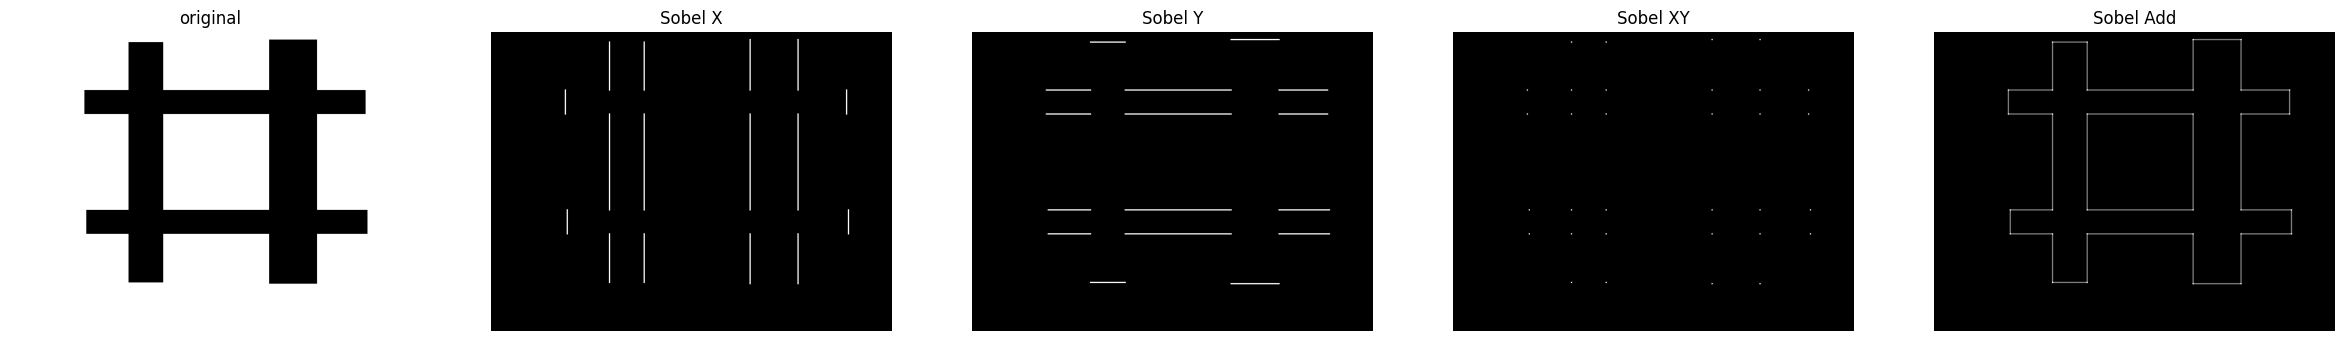

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
o = cv2.imread('sobel4.bmp', cv2.IMREAD_GRAYSCALE)
sobelx = cv2.Sobel(o, cv2.CV_64F, 1, 0)     # x方向求梯度
sobelx = cv2.convertScaleAbs(sobelx)        # 转回uint8  
sobely = cv2.Sobel(o, cv2.CV_64F, 0, 1)     # y方向求梯度
sobely = cv2.convertScaleAbs(sobely) 
sobelxy = cv2.Sobel(o, cv2.CV_64F, 1, 1)    # xy方向求梯度
sobelxy = cv2.convertScaleAbs(sobelxy)  
sobeladd = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0) # x和y方向的梯度图像加权相加

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
sobelx = cv2.cvtColor(sobelx, cv2.COLOR_BGR2RGB)
sobely = cv2.cvtColor(sobely, cv2.COLOR_BGR2RGB)
sobelxy = cv2.cvtColor(sobelxy, cv2.COLOR_BGR2RGB)
sobeladd = cv2.cvtColor(sobeladd, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 6))
plt.subplot(151)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(152)
plt.imshow(sobelx)
plt.title("Sobel X")
plt.axis("off")
plt.subplot(153)
plt.imshow(sobely)
plt.title("Sobel Y")
plt.axis("off")
plt.subplot(154)
plt.imshow(sobelxy)
plt.title("Sobel XY")
plt.axis("off")
plt.subplot(155)
plt.imshow(sobeladd)
plt.title("Sobel Add")
plt.axis("off")
plt.show()
  